In [109]:
"""
 Synthetic Data Generation

This script generates synthetic data for testing purposes.
"""
# Import necessary libraries
import random

# Constants
PROBA_COMPLEMENTARY_ITEMS = 0.7
PROBA_NEUTRAL_ITEMS = 0.3
DICT_ITEMS_CLASSES = {
    "nest0": ({0,1,2}, [-1, 1, 0, 0]) ,
    "nest1": ({3,4,5}, [1, -1, 0, 0]),
    "nest2": ({6}, [0, 0, -1, 0]),
    "nest3": ({7}, [0, 0, 0, -1])
}


In [110]:
ASSORTMENT = {0, 1, 2, 3, 4, 5, 6, 7}
AVAILABLE_SETS = list(KEY for KEY, VALUE in DICT_ITEMS_CLASSES.items() if VALUE[0].intersection(ASSORTMENT))

# Selection of the first item
def select_first_item():
    chosen_nest = random.choice(AVAILABLE_SETS)
    chosen_item = random.choice(list(DICT_ITEMS_CLASSES[chosen_nest][0]))
    return chosen_item, chosen_nest

# Complete the basket
def complete_basket(first_item, first_nest):
    basket = {first_item}
    first_key_index = int(first_nest[-1])
    for key in AVAILABLE_SETS:
        nest, relations = DICT_ITEMS_CLASSES[key]
        if relations[first_key_index] == 1 and random.random() < PROBA_COMPLEMENTARY_ITEMS:
            basket.add(random.choice(list(nest)))
        elif relations[first_key_index] == 0 and random.random() < PROBA_NEUTRAL_ITEMS:
            basket.add(random.choice(list(nest)))
    return basket


# Adding some random noise
def add_noise(basket):
    noise_proba = [0, 0.15]
    for item in ASSORTMENT:
        proba = random.choice(noise_proba)
        if item not in basket and random.random() < proba:
            basket.add(item)
    return list(basket)

        

In [111]:
print("Generating synthetic data...")
for _ in range(20):
    first_item, first_nest = select_first_item()
    basket = complete_basket(first_item, first_nest)
    basket = add_noise(basket)
    print("Generated basket:", basket)

Generating synthetic data...
Generated basket: [2, 6, 7]
Generated basket: [0, 2, 5, 6]
Generated basket: [6, 7]
Generated basket: [1, 6]
Generated basket: [7]
Generated basket: [2, 3, 7]
Generated basket: [1, 4, 6, 7]
Generated basket: [1, 5]
Generated basket: [0, 4, 5, 7]
Generated basket: [7]
Generated basket: [3, 4]
Generated basket: [0, 4]
Generated basket: [1]
Generated basket: [2, 3, 6]
Generated basket: [5, 6, 7]
Generated basket: [4]
Generated basket: [2, 7]
Generated basket: [6, 7]
Generated basket: [2, 6]
Generated basket: [1, 5]


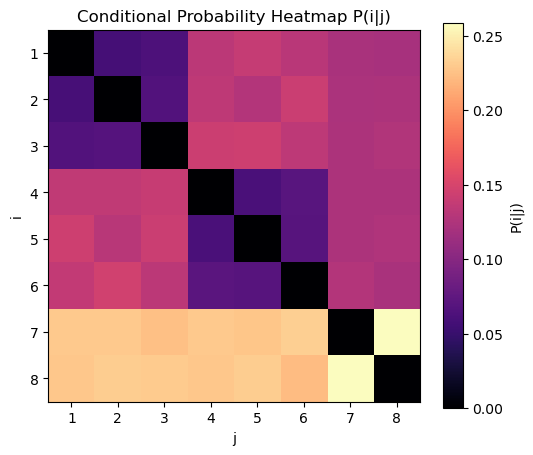

In [108]:
import numpy as np

M = np.zeros((8,8))

for _ in range(10000):
    first_item, first_nest = select_first_item()
    basket = complete_basket(first_item, first_nest)
    basket = add_noise(basket)
    basket = list(basket)
    for i in basket:
        for j in basket:
            if i != j:
                M[i][j] += 1



M = M / np.sum(M, axis=0, keepdims=True)
np.set_printoptions(precision=2, suppress=True)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(M, cmap='magma', interpolation='nearest')
plt.colorbar(label='P(i|j)')
plt.title('Conditional Probability Heatmap P(i|j)')
plt.xlabel('j')
plt.ylabel('i')
plt.xticks(ticks=np.arange(8), labels=np.arange(1,9))
plt.yticks(ticks=np.arange(8), labels=np.arange(1,9))
plt.show()